In [53]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

#载入数据
digits = load_digits()
X, y = digits.data, digits.target
print(f"原始数据: X.shape={X.shape}, y.shape={y.shape}")
print(f"类别分布: {np.unique(y, return_counts=True)}")

#划分训练集(60%)、验证集(20%)、测试集(20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n划分并标准化后:")
print(f"训练集: {X_train_scaled.shape}, {y_train.shape}")
print(f"验证集: {X_val_scaled.shape}, {y_val.shape}")
print(f"测试集: {X_test_scaled.shape}, {y_test.shape}")

原始数据: X.shape=(1797, 64), y.shape=(1797,)
类别分布: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([178, 182, 177, 183, 181, 182, 181, 179, 174, 180]))

划分并标准化后:
训练集: (1078, 64), (1078,)
验证集: (359, 64), (359,)
测试集: (360, 64), (360,)


In [54]:
#转换为torch张量
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.LongTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.LongTensor(y_test)

#创建TensorDataset和DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"\nDataLoader创建完成:")
print(f"train_loader: {len(train_loader)} batches (batch_size=64)")
print(f"val_loader: {len(val_loader)} batches (batch_size=256)")
print(f"test_loader: {len(test_loader)} batches (batch_size=256)")


DataLoader创建完成:
train_loader: 17 batches (batch_size=64)
val_loader: 2 batches (batch_size=256)
test_loader: 2 batches (batch_size=256)


In [55]:
#定义两层MLP模型
class TwoLayerMLP(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128, output_dim=10):
        super(TwoLayerMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

#实例化
model = TwoLayerMLP()
print(model)

# 计算参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

TwoLayerMLP(
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

总参数量: 9,610
可训练参数量: 9,610


In [56]:
#训练模型
num_epochs = 50
train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        # 前向传播
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # 反向传播和优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # 验证阶段
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)

    # 每10个epoch打印一次
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:2d}/{num_epochs}] - "
              f"Train Loss: {epoch_loss:.4f}, "
              f"Val Accuracy: {val_accuracy:.2f}%")

print("\n训练完成!")

Epoch [ 1/50] - Train Loss: 2.0359, Val Accuracy: 71.87%
Epoch [10/50] - Train Loss: 0.1644, Val Accuracy: 94.99%
Epoch [20/50] - Train Loss: 0.0521, Val Accuracy: 96.38%
Epoch [30/50] - Train Loss: 0.0232, Val Accuracy: 97.21%
Epoch [40/50] - Train Loss: 0.0125, Val Accuracy: 97.49%
Epoch [50/50] - Train Loss: 0.0077, Val Accuracy: 97.49%

训练完成!


In [57]:
#评估测试集
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

test_accuracy = 100 * correct / total
print(f"测试集准确率: {test_accuracy:.2f}% ({correct}/{total})")

测试集准确率: 97.78% (352/360)


In [58]:
#保存模型
torch.save(model.state_dict(), 'digits_mlp.pth')
print("模型已保存为 'digits_mlp.pth'")

# 创建新模型并加载权重
new_model = TwoLayerMLP()
new_model.load_state_dict(torch.load('digits_mlp.pth'))
print("新模型已加载权重")

# 用新模型再次评估测试集
new_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = new_model(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

new_test_accuracy = 100 * correct / total
print(f"加载后的模型测试准确率: {new_test_accuracy:.2f}%")

模型已保存为 'digits_mlp.pth'
新模型已加载权重
加载后的模型测试准确率: 97.78%


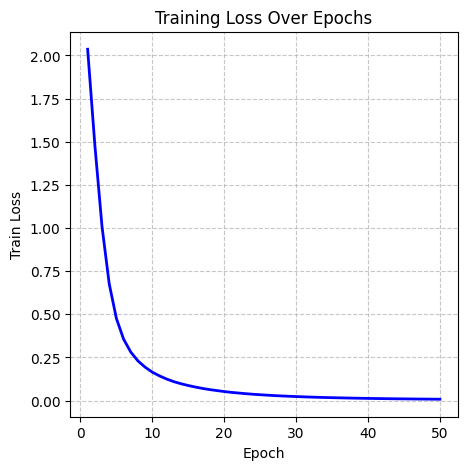

In [59]:
#绘制训练曲线
plt.figure(figsize=(5, 5))
plt.plot(range(1, num_epochs+1), train_losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()